# **CNN FROM SCRATCH**
**airplane VS automobile (CIFAR-10)**


In [ ]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: []


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import datasets
from tensorflow.keras import layers
from tensorflow.keras import models

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

print(x_train.shape)
print(x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2281s 13us/step
(50000, 32, 32, 3)
(10000, 32, 32, 3)


In [ ]:
train_filter = np.where(
    (y_train == 0) | (y_train == 1)
)[0]

test_filter = np.where(
    (y_test == 0) | (y_test == 1)
)[0]

x_train = x_train[train_filter]
y_train = y_train[train_filter]

x_test = x_test[test_filter]
y_test = y_test[test_filter]

In [ ]:
print("Training Data :", len(x_train))
print("Testing Data :", len(x_test))

Training Data : 10000
Testing Data : 2000


In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [ ]:
x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.15,
    random_state=42
)

In [ ]:
print("Train :", x_train.shape)
print("Validation :", x_val.shape)
print("Test :", x_test.shape)

Train : (8500, 32, 32, 3)
Validation : (1500, 32, 32, 3)
Test : (2000, 32, 32, 3)


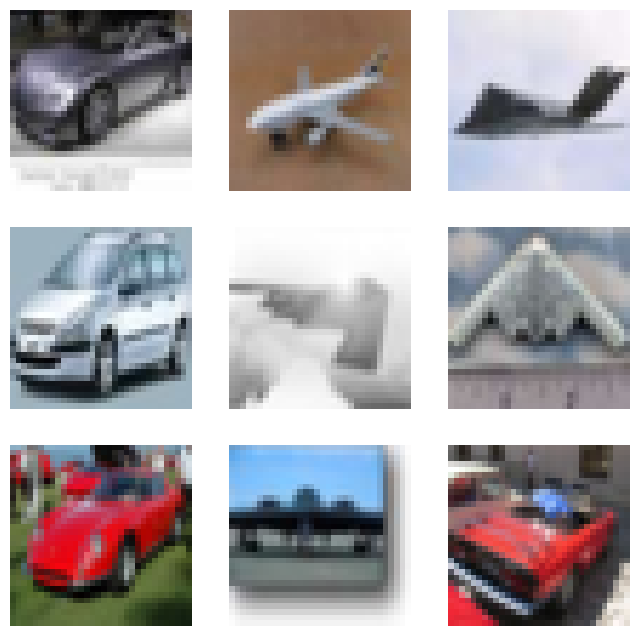

In [ ]:
plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.axis("off")

plt.show()

In [ ]:
cnn_model = models.Sequential([

    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    layers.Flatten(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.5),

    layers.Dense(
        1,
        activation='sigmoid'
    )
])

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,649 (1.36 MB)

 Trainable params: 355,649 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_cnn = cnn_model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 15s 50ms/step - accuracy: 0.8062 - loss: 0.4127 - val_accuracy: 0.8707 - val_loss: 0.2807
Epoch 2/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - accuracy: 0.8952 - loss: 0.2546 - val_accuracy: 0.9120 - val_loss: 0.1958
Epoch 3/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - accuracy: 0.9220 - loss: 0.2003 - val_accuracy: 0.9353 - val_loss: 0.1535
Epoch 4/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - accuracy: 0.9421 - loss: 0.1567 - val_accuracy: 0.9433 - val_loss: 0.1547
Epoch 5/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - accuracy: 0.9502 - loss: 0.1314 - val_accuracy: 0.9587 - val_loss: 0.1219
Epoch 6/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - accuracy: 0.9618 - loss: 0.1027 - val_accuracy: 0.9553 - val_loss: 0.1184
Epoch 7/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.9651 - loss: 0.0935 - val_accuracy: 0.9573 - val_loss: 0.1153
Epoch 8/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.9711 - loss: 0.0787 - 

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(
    x_test,
    y_test
)

print("Test Accuracy :", cnn_test_acc)
print("Test Loss :", cnn_test_loss)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9415 - loss: 0.1799
Test Accuracy : 0.9415000081062317
Test Loss : 0.17993319034576416


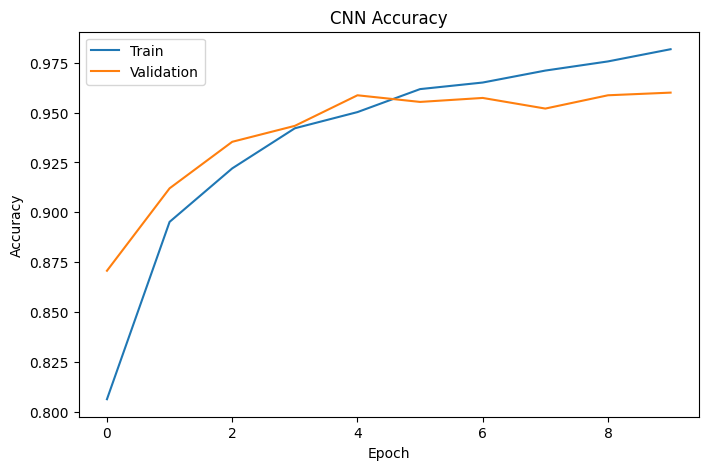

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['val_accuracy'])

plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train','Validation'])

plt.show()

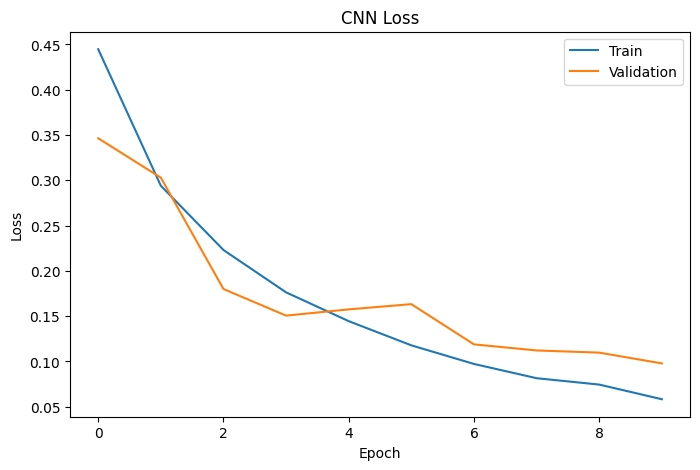

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_cnn.history['loss'])
plt.plot(history_cnn.history['val_loss'])

plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train','Validation'])

plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


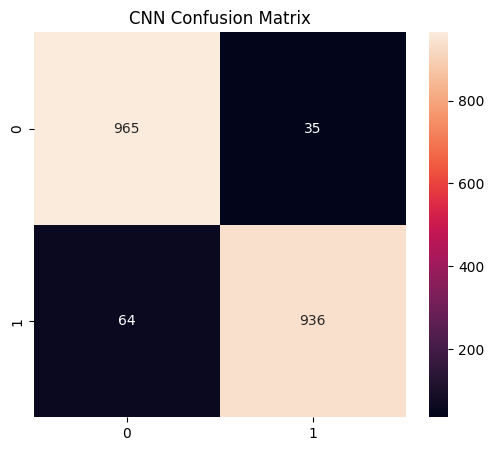

In [ ]:
y_pred = cnn_model.predict(x_test)

y_pred = (y_pred > 0.5)

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("CNN Confusion Matrix")

plt.show()

In [ ]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      1000
           1       0.96      0.94      0.95      1000

    accuracy                           0.95      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000



# **TRANSFER LEARNING**
**cats VS dog**

In [ ]:
import os

print(os.listdir('/content'))

['.config', 'sample_data']


In [ ]:
import os

print(os.listdir('/content'))

['.config', 'sample_data']


In [ ]:
import zipfile

zip_path = "/content/dogs cats.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Ekstraksi selesai")

In [ ]:
import os

print(os.listdir("/content/dataset"))

In [ ]:
import os

print("Train:", os.listdir("/content/dataset/train"))
print("Test :", os.listdir("/content/dataset/test"))

In [ ]:
import os

print(os.listdir("/content/dataset/train/train")[:10])

In [ ]:
import os

base_dir = "/content/cats_dogs"

os.makedirs(base_dir, exist_ok=True)
os.makedirs(base_dir + "/cats", exist_ok=True)
os.makedirs(base_dir + "/dogs", exist_ok=True)

print("Folder berhasil dibuat")

In [ ]:
import os
import shutil

source_dir = "/content/dataset/train/train"

for filename in os.listdir(source_dir):

    if filename.startswith("cat"):
        shutil.copy(
            os.path.join(source_dir, filename),
            "/content/cats_dogs/cats"
        )

    elif filename.startswith("dog"):
        shutil.copy(
            os.path.join(source_dir, filename),
            "/content/cats_dogs/dogs"
        )

print("Selesai memisahkan cat dan dog")

In [ ]:
import os

print("Jumlah Cat :", len(os.listdir("/content/cats_dogs/cats")))
print("Jumlah Dog :", len(os.listdir("/content/cats_dogs/dogs")))

In [ ]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/cats_dogs",
    validation_split=0.2,
    subset="both",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

train_dataset, val_dataset = dataset

In [ ]:
print(train_dataset)
print(val_dataset)

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(
    buffer_size=AUTOTUNE
)

val_dataset = val_dataset.prefetch(
    buffer_size=AUTOTUNE
)

In [ ]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

In [ ]:
base_model.trainable = False

In [ ]:
model_tl = tf.keras.Sequential([

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        1,
        activation='sigmoid'
    )
])

In [ ]:
model_tl.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_tl = model_tl.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5
)

In [ ]:
loss_tl, acc_tl = model_tl.evaluate(val_dataset)

print("Transfer Learning Accuracy :", acc_tl)
print("Transfer Learning Loss :", loss_tl)

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_tl.history['accuracy'])
plt.plot(history_tl.history['val_accuracy'])

plt.title('Transfer Learning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train','Validation'])

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_tl.history['loss'])
plt.plot(history_tl.history['val_loss'])

plt.title('Transfer Learning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train','Validation'])

plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in val_dataset:
    predictions = model_tl.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend((predictions > 0.5).astype("int32").flatten())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Transfer Learning Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Cat", "Dog"]
    )
)